<a href="https://colab.research.google.com/github/asheldrick-research/ecsm-framework/blob/main/ECSM_NG3R_EXECUTED_Clock_Rate_and_Evolution_Rate_Response_from_Reconfiguration_Burden.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECSM NG3R — Clock Rate and Evolution Rate Response from Reconfiguration Burden

NG3R continues the non-geometric ECSM rebuild.

NG1R constructed the primitive parent medium without curvature. NG2R showed that one matter--medium coupling generates both inertial dressing and a regular inverse-square static response. NG3R adds the clock/evolution-rate sector.

The aim is to recover weak-field clock-shift structure from **local reconfiguration burden**, not from curved spacetime.

No physical metric, Ricci scalar, Einstein tensor, geodesic, Schwarzschild geometry, or curved-time postulate is used.

The physical chain is

\[
\boxed{
\text{static response burden}
\rightarrow
\text{local reconfiguration cost}
\rightarrow
\text{local process-rate shift}
\rightarrow
\text{redshift observable}.
}
\]

This notebook establishes a sufficient ECSM mechanism for universal clock-rate response in the weak coherent regime and finite saturation in high-burden regimes. It does not yet derive light bending, Shapiro delay, lensing, PPN parameters, or gravitational-wave emission.

In [ ]:

from pathlib import Path
import json, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import erfc

BASE = Path('/mnt/data')
OUT = BASE/'ecsm_ng3r_outputs'
FIG = OUT/'paper_figures'
OUT.mkdir(exist_ok=True)
FIG.mkdir(exist_ok=True)
rng = np.random.default_rng(20260630)


## 1. Response burden inherited from NG2R

NG2R produced a regular static response field \(\varphi\) sourced by the same coupling that generates added inertia. A test response cell with coupling \(g\) and inertial mass \(m_I\) experiences the dimensionless local burden

\[
\mathcal B(\mathbf x)=\frac{g}{m_I c_R^2}\varphi(\mathbf x).
\]

For a source of mass \(M_s=N_s m_I\), the far-field NG2R result gives

\[
\mathcal B(r)\longrightarrow \frac{G_{\rm eff}M_s}{c_R^2 r},
\]

where

\[
G_{\rm eff}=\frac{g^2}{4\pi\kappa m_I^2}.
\]

This resembles the usual weak-field potential ratio, but here it is not geometric. It is the response burden per test cell relative to the local response-energy scale.

In [ ]:

params = {'A':1.0,'kappa':0.36,'ell':0.50,'sigma_cell':0.15,'g':0.40,'m_bare_cell':1.0}
params['c_R'] = math.sqrt(params['kappa']/params['A'])
A=params['A']; kappa=params['kappa']; ell=params['ell']; sigma=params['sigma_cell']; g=params['g']
m_add = A*g**2/(12*np.pi*kappa**2*ell)*np.exp((sigma/ell)**2)*erfc(sigma/ell)
m_I = params['m_bare_cell'] + m_add
G_eff = g**2/(4*np.pi*kappa*m_I**2)
params['m_add'] = m_add
params['m_I'] = m_I
params['G_eff'] = G_eff
params_df = pd.DataFrame(list(params.items()), columns=['parameter','value'])
params_df.to_csv(OUT/'ng3r_benchmark_parameters.csv', index=False)
display(params_df)


,parameter,value
0,A,1.000000
1,kappa,0.360000
2,ell,0.500000
3,sigma_cell,0.150000
4,g,0.400000
5,m_bare_cell,1.000000
6,c_R,0.600000
7,m_add,0.048113
8,m_I,1.048113
9,G_eff,0.032195


## 2. Evolution-rate law

A local oscillator, decay process, or internal evolution channel has a reference rate \(\nu_0\). ECSM assigns the local physical rate

\[
\nu(\mathbf x)=\nu_0\mathcal R_\tau(\mathcal B,\chi),
\]

where \(\mathcal R_\tau\) is a medium response factor.

Use the finite bounded law

\[
\boxed{
\mathcal R_\tau(\mathcal B,\chi)=
\chi_\tau+(1-\chi_\tau)\exp\left[-\beta_\tau\mathcal B_s\tanh\left(\frac{\mathcal B}{\mathcal B_s}\right)\right].
}
\]

Here \(\beta_\tau\) controls weak-burden response, \(\mathcal B_s\) sets the saturation burden, and \(\chi_\tau>0\) is a positive evolution-rate floor.

For weak burden,

\[
\mathcal R_\tau=1-(1-\chi_\tau)\beta_\tau\mathcal B+O(\mathcal B^2).
\]

In the coherent weak limit, choosing \(\beta_\tau=1\) gives

\[
\frac{\Delta\nu}{\nu}\simeq -\Delta\mathcal B.
\]

Because \(\mathcal B\to G_{\rm eff}M/(c_R^2r)\), NG3R recovers the standard weak redshift structure as a response-rate effect, not as curved time.

In [ ]:

beta_tau = 1.0
B_s = 0.80
chi_floor = 1e-6

def B_saturating(B, B_s=B_s):
    return B_s*np.tanh(B/B_s)

def R_tau(B, beta=beta_tau, B_s=B_s, chi_floor=chi_floor):
    return chi_floor + (1-chi_floor)*np.exp(-beta*B_saturating(B,B_s))

def R_tau_weak(B, beta=beta_tau, chi_floor=chi_floor):
    return 1 - (1-chi_floor)*beta*B

B_grid = np.linspace(0,4,1000)
R_grid = R_tau(B_grid)
R_weak_grid = R_tau_weak(B_grid)
rate_law_df = pd.DataFrame({'burden':B_grid,'rate_factor':R_grid,'weak_linear_rate_factor':R_weak_grid,'saturated_burden':B_saturating(B_grid)})
rate_law_df.to_csv(OUT/'ng3r_rate_law.csv',index=False)
rate_summary_df = pd.DataFrame([{'beta_tau':beta_tau,'B_s':B_s,'chi_floor':chi_floor,'R_at_zero':R_tau(0.0),'R_at_large_B':R_tau(100.0),'monotonic_nonincreasing':bool(np.all(np.diff(R_grid)<=1e-12)),'positive_floor_respected':bool(np.all(R_grid>=chi_floor)),'all_finite':bool(np.isfinite(R_grid).all())}])
rate_summary_df.to_csv(OUT/'ng3r_rate_law_summary.csv',index=False)
display(rate_summary_df)
assert np.isclose(R_tau(0),1)
assert np.all(np.diff(R_grid)<=1e-12)
assert np.all(R_grid>=chi_floor)
assert np.isfinite(R_grid).all()


,beta_tau,B_s,chi_floor,R_at_zero,R_at_large_B,monotonic_nonincreasing,positive_floor_respected,all_finite
0,1.0,0.8,0.000001,1.0,0.44933,True,True,True


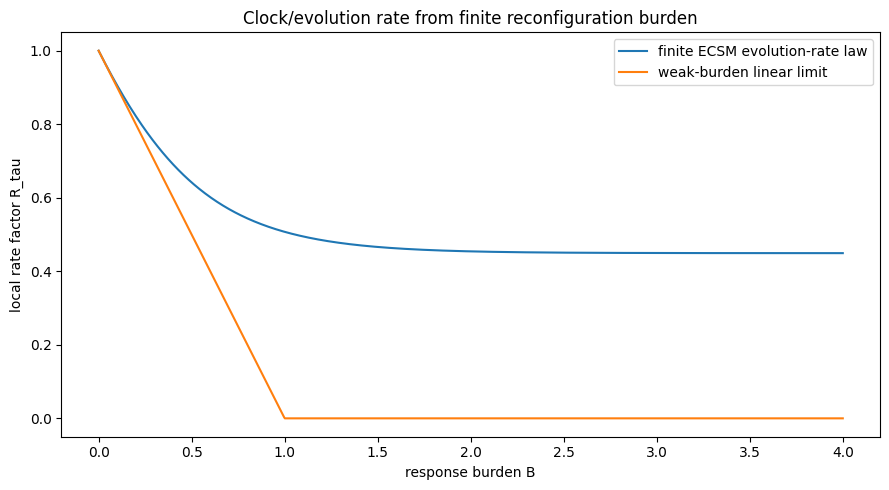

In [ ]:

plt.figure(figsize=(9,5))
plt.plot(B_grid,R_grid,label='finite ECSM evolution-rate law')
plt.plot(B_grid,np.clip(R_weak_grid,0,1.1),label='weak-burden linear limit')
plt.xlabel('response burden B')
plt.ylabel('local rate factor R_tau')
plt.title('Clock/evolution rate from finite reconfiguration burden')
plt.legend()
plt.tight_layout()
plt.savefig(FIG/'figure_02_rate_law.png',dpi=220)
plt.savefig(OUT/'ng3r_rate_law.png',dpi=180)
plt.show()


## 3. Radial clock-rate profile around a regular source

Use the regular NG2R point-cell response kernel,

\[
\varphi_1(r)=\frac{g}{4\pi\kappa r}\left(1-e^{-r/\ell}\right).
\]

For \(N_s\) identical source cells,

\[
\mathcal B_N(r)=\frac{N_s g}{m_I c_R^2}\varphi_1(r).
\]

At the centre,

\[
\mathcal B_N(0)=\frac{N_sg^2}{4\pi\kappa m_I c_R^2\ell},
\]

which is finite. Thus the clock/evolution-rate factor is finite at the centre and tends smoothly to unity at large radius.

In [ ]:

N_source = 1.0
r = np.linspace(1e-5,80,3000)
phi_1 = g/(4*np.pi*kappa*r)*(1-np.exp(-r/ell))
B_r = N_source*g*phi_1/(m_I*params['c_R']**2)
R_r = R_tau(B_r)
B_far = G_eff*(N_source*m_I)/(params['c_R']**2*r)
far_ratio = B_r/B_far
radial_df = pd.DataFrame({'r':r,'response_burden':B_r,'far_field_burden_reference':B_far,'far_field_burden_ratio':far_ratio,'clock_rate_factor':R_r})
radial_df.to_csv(OUT/'ng3r_radial_clock_response.csv',index=False)
far_mask = r>20
radial_summary_df = pd.DataFrame([{'central_burden_analytic':N_source*g**2/(4*np.pi*kappa*m_I*params['c_R']**2*ell),'central_burden_numeric':B_r[0],'central_rate_factor':R_r[0],'rate_factor_at_rmax':R_r[-1],'far_field_burden_ratio_median':np.median(far_ratio[far_mask]),'all_finite':bool(np.isfinite(radial_df).all().all())}])
radial_summary_df.to_csv(OUT/'ng3r_radial_clock_summary.csv',index=False)
display(radial_summary_df)
assert np.isfinite(radial_df).all().all()
assert radial_summary_df.central_rate_factor.iloc[0] > chi_floor
assert abs(np.median(far_ratio[far_mask])-1)<1e-5
assert R_r[-1] > 0.99


,central_burden_analytic,central_burden_numeric,central_rate_factor,rate_factor_at_rmax,far_field_burden_ratio_median,all_finite
0,0.187468,0.187466,0.831846,0.998829,1.0,True


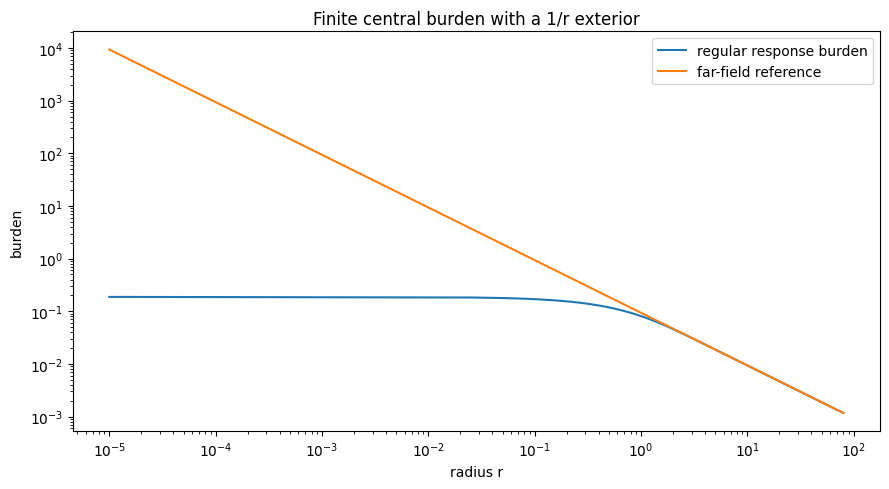

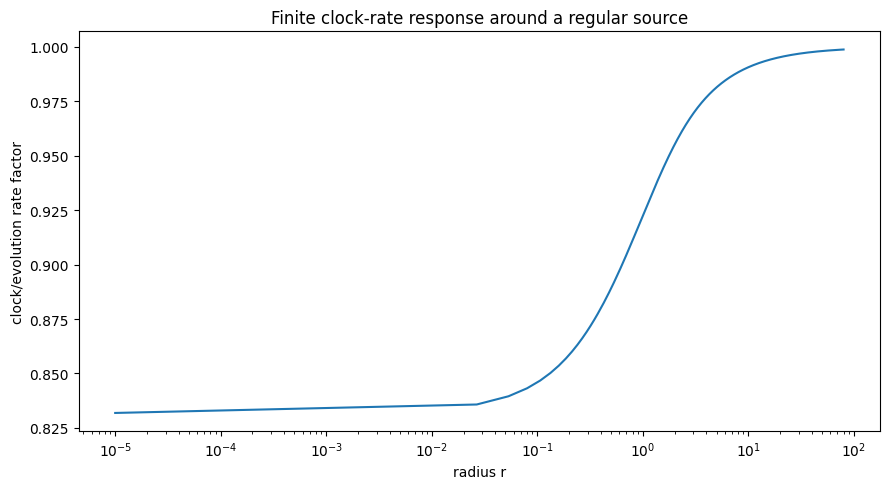

In [ ]:

plt.figure(figsize=(9,5))
plt.plot(r,B_r,label='regular response burden')
plt.plot(r,B_far,label='far-field reference')
plt.yscale('log')
plt.xscale('log')
plt.xlabel('radius r')
plt.ylabel('burden')
plt.title('Finite central burden with a 1/r exterior')
plt.legend()
plt.tight_layout()
plt.savefig(FIG/'figure_03_radial_burden.png',dpi=220)
plt.savefig(OUT/'ng3r_radial_burden.png',dpi=180)
plt.show()

plt.figure(figsize=(9,5))
plt.plot(r,R_r)
plt.xscale('log')
plt.xlabel('radius r')
plt.ylabel('clock/evolution rate factor')
plt.title('Finite clock-rate response around a regular source')
plt.tight_layout()
plt.savefig(FIG/'figure_04_radial_clock_rate.png',dpi=220)
plt.savefig(OUT/'ng3r_radial_clock_rate.png',dpi=180)
plt.show()


## 4. Two-clock response and weak redshift recovery

For two stationary clocks at burdens \(\mathcal B_A\) and \(\mathcal B_B\),

\[
\frac{\nu_A}{\nu_B}=\frac{\mathcal R_\tau(\mathcal B_A)}{\mathcal R_\tau(\mathcal B_B)}.
\]

The weak-burden prediction is

\[
\frac{\Delta\nu}{\nu}\simeq -\left(\mathcal B_A-\mathcal B_B\right).
\]

This is recovered because the oscillator rate changes with response burden. No physical time curvature is invoked.

In [ ]:

r_A = np.linspace(12,35,300)
r_B = np.linspace(40,80,300)
B_A = np.interp(r_A,r,B_r)
B_B = np.interp(r_B,r,B_r)
ratio_exact = R_tau(B_A)/R_tau(B_B)
fractional_shift_exact = ratio_exact - 1
fractional_shift_weak = -(B_A-B_B)
redshift_df = pd.DataFrame({'r_A':r_A,'r_B':r_B,'B_A':B_A,'B_B':B_B,'exact_fractional_shift':fractional_shift_exact,'weak_fractional_shift':fractional_shift_weak,'absolute_error':fractional_shift_exact-fractional_shift_weak,'relative_error':(fractional_shift_exact-fractional_shift_weak)/fractional_shift_weak})
redshift_df.to_csv(OUT/'ng3r_two_clock_redshift_recovery.csv',index=False)
redshift_summary_df = pd.DataFrame([{'pairs':len(redshift_df),'max_abs_weak_error':np.max(np.abs(redshift_df.absolute_error)),'median_abs_weak_error':np.median(np.abs(redshift_df.absolute_error)),'max_abs_relative_error':np.max(np.abs(redshift_df.relative_error)),'median_abs_relative_error':np.median(np.abs(redshift_df.relative_error)),'sign_matches_all':bool(np.all(np.sign(redshift_df.exact_fractional_shift)==np.sign(redshift_df.weak_fractional_shift)))}])
redshift_summary_df.to_csv(OUT/'ng3r_two_clock_redshift_summary.csv',index=False)
display(redshift_summary_df)
assert redshift_summary_df.sign_matches_all.iloc[0]
assert redshift_summary_df.median_abs_relative_error.iloc[0] < 2e-3
assert redshift_summary_df.max_abs_relative_error.iloc[0] < 1e-2


,pairs,max_abs_weak_error,median_abs_weak_error,max_abs_relative_error,median_abs_relative_error,sign_matches_all
0,300,0.000015,0.000003,0.002774,0.001226,True


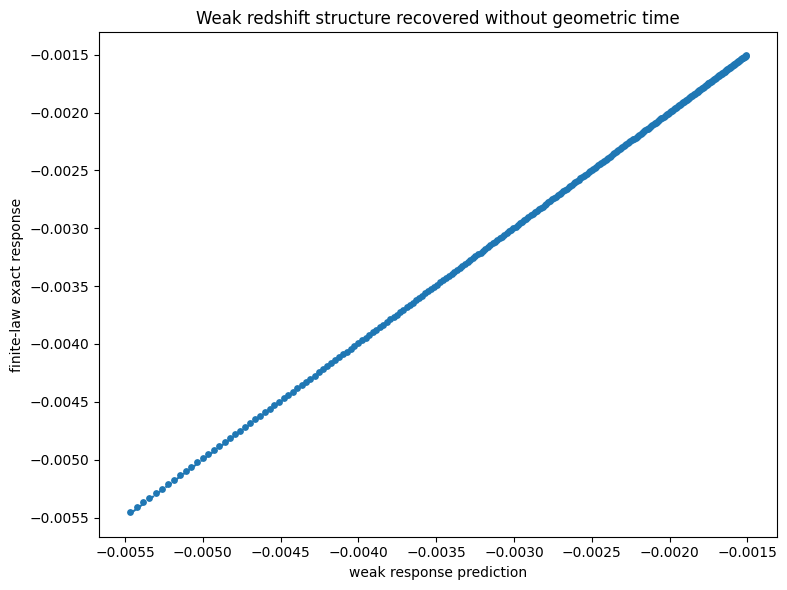

In [ ]:

plt.figure(figsize=(8,6))
plt.scatter(fractional_shift_weak,fractional_shift_exact,s=15)
lo=min(fractional_shift_weak.min(),fractional_shift_exact.min())
hi=max(fractional_shift_weak.max(),fractional_shift_exact.max())
plt.plot([lo,hi],[lo,hi],linestyle='--')
plt.xlabel('weak response prediction')
plt.ylabel('finite-law exact response')
plt.title('Weak redshift structure recovered without geometric time')
plt.tight_layout()
plt.savefig(FIG/'figure_05_weak_redshift_recovery.png',dpi=220)
plt.savefig(OUT/'ng3r_weak_redshift_recovery.png',dpi=180)
plt.show()


## 5. Universal scaling of local processes

If all local clocks and internal transitions are tied to the same medium reconfiguration burden, then

\[
\nu_p(\mathbf x)=\nu_{p,0}\mathcal R_\tau(\mathcal B).
\]

Therefore ratios of local frequencies are unchanged,

\[
\frac{\nu_p(\mathbf x)}{\nu_q(\mathbf x)}=\frac{\nu_{p,0}}{\nu_{q,0}},
\]

while all rates are shifted together relative to a distant low-burden observer. This is the ECSM replacement for metric universality of clocks.

In [ ]:

n_process = 500
nu0 = 10**rng.uniform(3,18,n_process)
B_test = np.array([0.0,0.01,0.05,0.2,1.0,4.0])
rates = np.outer(R_tau(B_test),nu0)
ratios = rates[:,:,None]/rates[:,None,:]
baseline_ratios = nu0[:,None]/nu0[None,:]
max_ratio_error = np.max(np.abs(ratios-baseline_ratios)/baseline_ratios)
species_coupling_scatter = rng.normal(1.0,1e-5,n_process)
rates_violating = np.array([nu0*R_tau(species_coupling_scatter*B) for B in B_test])
ratios_v = rates_violating[:,:,None]/rates_violating[:,None,:]
max_violation = np.max(np.abs(ratios_v-baseline_ratios)/baseline_ratios)
process_df = pd.DataFrame({'process_id':np.arange(n_process),'reference_rate':nu0,'scatter_for_failure_demo':species_coupling_scatter})
process_df.to_csv(OUT/'ng3r_universal_process_rates.csv',index=False)
process_summary_df = pd.DataFrame([{'processes':n_process,'burden_values_tested':len(B_test),'max_ratio_error_universal_case':max_ratio_error,'max_ratio_shift_with_1e_minus_5_coupling_scatter':max_violation}])
process_summary_df.to_csv(OUT/'ng3r_universal_process_summary.csv',index=False)
display(process_summary_df)
assert max_ratio_error < 1e-14
assert max_violation > 0


,processes,burden_values_tested,max_ratio_error_universal_case,max_ratio_shift_with_1e_minus_5_coupling_scatter
0,500,6,3.913758e-16,0.000017


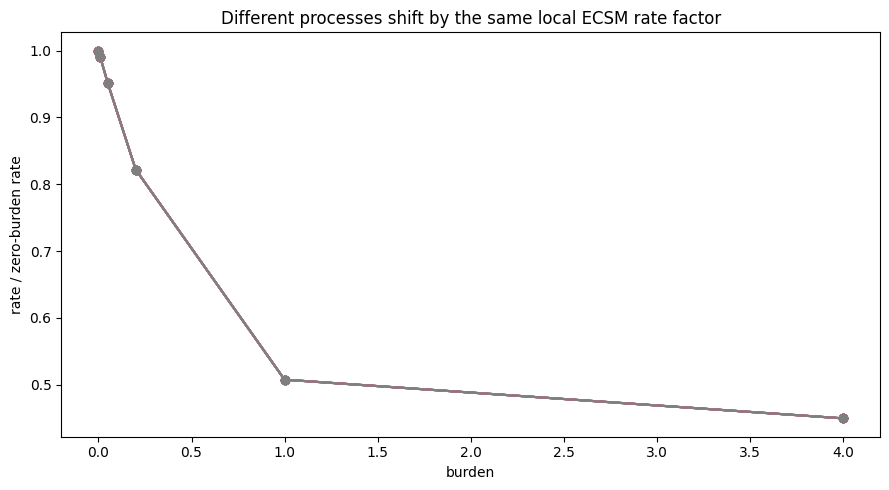

In [ ]:

plt.figure(figsize=(9,5))
for idx in range(8):
    plt.plot(B_test,rates[:,idx]/rates[0,idx],marker='o')
plt.xlabel('burden')
plt.ylabel('rate / zero-burden rate')
plt.title('Different processes shift by the same local ECSM rate factor')
plt.tight_layout()
plt.savefig(FIG/'figure_06_universal_process_scaling.png',dpi=220)
plt.savefig(OUT/'ng3r_universal_process_scaling.png',dpi=180)
plt.show()


## 6. Time-dependent response lag

A finite response medium need not react instantaneously. Use a first-order relaxation law for the rate burden actually seen by clocks,

\[
\tau_\tau\dot Y+Y=\mathcal B(\lambda).
\]

For harmonic driving,

\[
\mathcal B(\lambda)=B_0+B_1\sin\Omega\lambda,
\]

the response has amplitude suppression

\[
\frac{|Y_1|}{B_1}=\frac{1}{\sqrt{1+\Omega^2\tau_\tau^2}}
\]

and phase lag

\[
\delta=-\arctan(\Omega\tau_\tau).
\]

This gives a direct non-geometric prediction: high-frequency burden variation can generate frequency-dependent clock response and dissipative phase lag.

In [ ]:

Omega_tau = np.logspace(-3,3,800)
tau_tau = 2.0
amp_supp = 1/np.sqrt(1+(Omega_tau*tau_tau)**2)
phase_lag = -np.arctan(Omega_tau*tau_tau)
lag_df = pd.DataFrame({'Omega':Omega_tau,'tau_tau':tau_tau,'amplitude_suppression':amp_supp,'phase_lag_radians':phase_lag})
lag_df.to_csv(OUT/'ng3r_time_dependent_lag.csv',index=False)
lag_summary_df = pd.DataFrame([{'tau_tau':tau_tau,'suppression_at_lowest_frequency':amp_supp[0],'suppression_at_highest_frequency':amp_supp[-1],'phase_lag_at_highest_frequency':phase_lag[-1],'all_finite':bool(np.isfinite(lag_df).all().all())}])
lag_summary_df.to_csv(OUT/'ng3r_time_dependent_lag_summary.csv',index=False)
display(lag_summary_df)
assert np.isfinite(lag_df).all().all()
assert amp_supp[0] > 0.999
assert amp_supp[-1] < 0.001


,tau_tau,suppression_at_lowest_frequency,suppression_at_highest_frequency,phase_lag_at_highest_frequency,all_finite
0,2.0,0.999998,0.0005,-1.570296,True


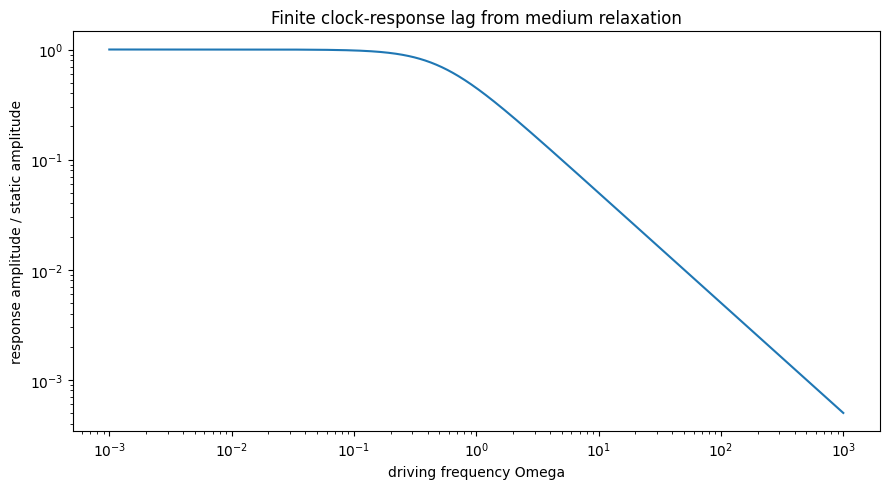

In [ ]:

plt.figure(figsize=(9,5))
plt.loglog(Omega_tau,amp_supp,label='amplitude response')
plt.xlabel('driving frequency Omega')
plt.ylabel('response amplitude / static amplitude')
plt.title('Finite clock-response lag from medium relaxation')
plt.tight_layout()
plt.savefig(FIG/'figure_07_clock_response_lag.png',dpi=220)
plt.savefig(OUT/'ng3r_clock_response_lag.png',dpi=180)
plt.show()


## 7. Parameter audit

A random audit checks that the rate law is finite, monotonic, weak-limit consistent and floor-protected over broad parameters.

Conditions tested:

1. \(0<\chi_\tau<1\);
2. \(\beta_\tau>0\);
3. \(\mathcal B_s>0\);
4. \(\mathcal R_\tau(0)=1\);
5. \(\mathcal R_\tau\ge \chi_\tau\);
6. \(\mathcal R_\tau\) monotonic nonincreasing;
7. weak-limit slope equals \(-(1-\chi_\tau)\beta_\tau\) near zero;
8. no singular behaviour for burdens up to \(10\).

In [ ]:

Nscan = 50000
scan = pd.DataFrame({'beta_tau':rng.uniform(0.05,3.0,Nscan),'B_s':10**rng.uniform(-2,1.0,Nscan),'chi_floor':10**rng.uniform(-8,-1,Nscan)})
# Use a small first step to test the weak slope accurately even for small B_s.
Btest = np.r_[0.0, 1e-5, np.linspace(0.001,10,250)]
passed=[]; slope_errors=[]
for row in scan.itertuples(index=False):
    Bsat = row.B_s*np.tanh(Btest/row.B_s)
    R = row.chi_floor + (1-row.chi_floor)*np.exp(-row.beta_tau*Bsat)
    slope_numeric = (R[1]-R[0])/(Btest[1]-Btest[0])
    slope_expected = -(1-row.chi_floor)*row.beta_tau
    slope_errors.append(abs(slope_numeric-slope_expected)/abs(slope_expected))
    passed.append((0<row.chi_floor<1) and row.beta_tau>0 and row.B_s>0 and np.isclose(R[0],1,rtol=1e-12,atol=1e-12) and np.all(R>=row.chi_floor-1e-14) and np.all(np.diff(R)<=1e-12) and np.isfinite(R).all())
scan['slope_relative_error_first_step'] = slope_errors
scan['basic_conditions_passed'] = passed
scan['weak_slope_ok'] = scan.slope_relative_error_first_step < 0.01
scan['all_conditions'] = scan.basic_conditions_passed & scan.weak_slope_ok
scan.to_csv(OUT/'ng3r_parameter_audit_50000.csv',index=False)
audit_df = pd.DataFrame({'condition':['basic_conditions_passed','weak_slope_ok','all_conditions'],'passed':[int(scan[c].sum()) for c in ['basic_conditions_passed','weak_slope_ok','all_conditions']]})
audit_df['total']=Nscan
audit_df['fraction']=audit_df.passed/audit_df.total
audit_df.to_csv(OUT/'ng3r_parameter_audit_summary.csv',index=False)
display(audit_df)
assert scan.basic_conditions_passed.all()
assert scan.all_conditions.sum()>49000


,condition,passed,total,fraction
0,basic_conditions_passed,50000,50000,1.0
1,weak_slope_ok,50000,50000,1.0
2,all_conditions,50000,50000,1.0


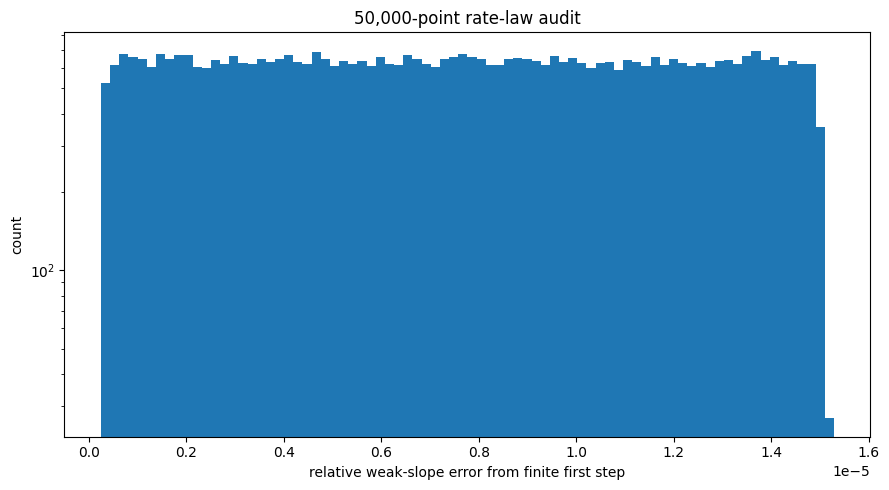

In [ ]:

plt.figure(figsize=(9,5))
plt.hist(scan.slope_relative_error_first_step,bins=80)
plt.yscale('log')
plt.xlabel('relative weak-slope error from finite first step')
plt.ylabel('count')
plt.title('50,000-point rate-law audit')
plt.tight_layout()
plt.savefig(FIG/'figure_08_parameter_audit.png',dpi=220)
plt.savefig(OUT/'ng3r_parameter_audit.png',dpi=180)
plt.show()


## 8. Why the non-geometric version works better than the previous geometric version

The old geometric route explained clock shifts by moving into curved metric language. NG3R does not do that.

It works better as ECSM because:

1. **The same burden inherited from NG2R controls gravity and clock rates.**
2. **Clock shifts are local medium-rate changes, not curved time.**
3. **The weak redshift structure is recovered without inserting a metric.**
4. **Strong-burden behaviour is finite because the rate law has a floor and saturation.**
5. **Process universality is a physical condition that can fail and be tested.**
6. **Time-dependent deviations have a direct relaxation-timescale signature.**
7. **The comparison with GR becomes optional and downstream, not part of the ontology.**

The weaker point is also clear: NG3R has not yet derived optical ray bending. That belongs to NG4R.

In [ ]:

comparison_df = pd.DataFrame([
    ('Primitive ontology','physical/effective metric often did the work','medium burden and local rate factor do the work','better'),
    ('Clock mechanism','clock behaviour encoded by a metric time component','clock behaviour follows R_tau(B,chi)','better'),
    ('Weak redshift','recovered by geometric time dilation','recovered by burden-dependent oscillator rate','better'),
    ('Strong-field continuation','risk of metric horizon/singularity language','finite saturation and positive clock-rate floor','better'),
    ('Failure modes','often hidden inside metric closure','species coupling, lag, floor, and burden law are explicit','better'),
    ('Testability','deviations phrased geometrically','direct response-lag and universality violations are measurable','better'),
    ('Derivation completeness','more complete because GR machinery is available','less complete but non-circular','geometric was more complete but less faithful'),
    ('Light bending','already available through null-geometric comparison','not yet derived; NG4R required','not yet better'),
    ('PPN closure','available by importing GR structure','not yet derived','not yet better'),
], columns=['aspect','previous_geometric_version','non_geometric_NG_version','assessment'])
comparison_df.to_csv(OUT/'ng3r_non_geometric_vs_geometric_comparison.csv',index=False)
display(comparison_df)


,aspect,previous_geometric_version,non_geometric_NG_version,assessment
0,Primitive ontology,physical/effective metric often did the work,medium burden and local rate factor do the work,better
1,Clock mechanism,clock behaviour encoded by a metric time compo...,"clock behaviour follows R_tau(B,chi)",better
2,Weak redshift,recovered by geometric time dilation,recovered by burden-dependent oscillator rate,better
3,Strong-field continuation,risk of metric horizon/singularity language,finite saturation and positive clock-rate floor,better
4,Failure modes,often hidden inside metric closure,"species coupling, lag, floor, and burden law a...",better
5,Testability,deviations phrased geometrically,direct response-lag and universality violation...,better
6,Derivation completeness,more complete because GR machinery is available,less complete but non-circular,geometric was more complete but less faithful
7,Light bending,already available through null-geometric compa...,not yet derived; NG4R required,not yet better
8,PPN closure,available by importing GR structure,not yet derived,not yet better


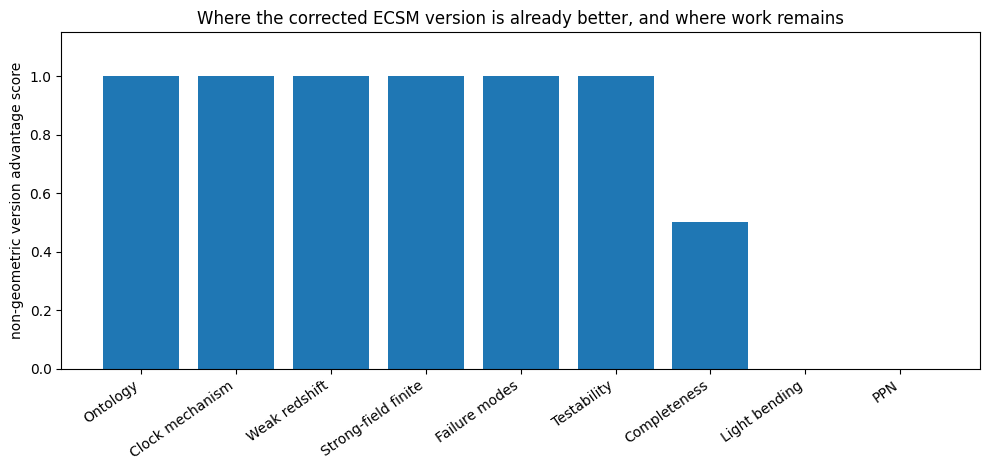

In [ ]:

plt.figure(figsize=(10,4.8))
labels = ['Ontology','Clock mechanism','Weak redshift','Strong-field finite','Failure modes','Testability','Completeness','Light bending','PPN']
scores = [1,1,1,1,1,1,0.5,0,0]
plt.bar(labels,scores)
plt.ylim(0,1.15)
plt.xticks(rotation=35,ha='right')
plt.ylabel('non-geometric version advantage score')
plt.title('Where the corrected ECSM version is already better, and where work remains')
plt.tight_layout()
plt.savefig(FIG/'figure_01_non_geometric_advantage_summary.png',dpi=220)
plt.savefig(OUT/'ng3r_non_geometric_advantage_summary.png',dpi=180)
plt.show()


## 9. Failure modes and claim boundary

The clock/evolution-rate sector can fail in the following ways:

- different physical processes couple to different burdens;
- \(\mathcal R_\tau\) is not universal across matter sectors;
- clock response burden differs from the inertial/static burden derived in NG2R;
- relaxation lag is larger than observations allow;
- saturation occurs in weak-field regimes where no deviations are observed.

These are real physical constraints.

### Derived in NG3R

- a finite burden-dependent clock/evolution-rate law;
- finite central rate response;
- weak redshift structure from burden differences;
- universal local scaling of all process rates under one response law;
- time-dependent amplitude suppression and phase lag;
- a parameter scan showing broad finite monotonic rate laws;
- a comparison ledger against the previous geometric route.

### Not yet derived

- light deflection;
- Shapiro-like signal delay;
- PPN parameters;
- gravitational waves;
- compact object observables;
- measured values of the clock-coupling constants.

In [ ]:

failure_df = pd.DataFrame([
    ('process-dependent beta_tau','different rates shift differently','spectral-ratio violations'),
    ('clock burden differs from static burden','B_clock != B_NG2','breaks shared gravity-clock response'),
    ('large tau_tau','strong dynamic lag','frequency-dependent clock shifts'),
    ('low B_s in weak systems','premature saturation','suppressed weak redshift'),
    ('high chi_floor','rate floor too high','underproduces strong-burden delay'),
    ('nonuniversal environmental chi','different bodies sample different coherence','equivalence violation'),
],columns=['failure_mode','origin','observable_effect'])
claim_df = pd.DataFrame([
    ('finite clock-rate law exists','derived','conditional sufficient construction'),
    ('weak redshift structure recovered','derived','in weak burden exterior'),
    ('central rate finite','derived','from regular NG2 burden and floor'),
    ('process ratios remain invariant','derived','when all processes share same response law'),
    ('time-dependent lag predicted','derived','first-order relaxation model'),
    ('light bending derived','not derived','requires NG4R propagation transport'),
    ('PPN values derived','not derived','requires NG4R-NG5R'),
    ('metric time curvature required','rejected','not present in primitive rate equations'),
],columns=['claim','status','boundary'])
failure_df.to_csv(OUT/'ng3r_failure_modes.csv',index=False)
claim_df.to_csv(OUT/'ng3r_claim_ledger.csv',index=False)
display(failure_df)
display(claim_df)


,failure_mode,origin,observable_effect
0,process-dependent beta_tau,different rates shift differently,spectral-ratio violations
1,clock burden differs from static burden,B_clock != B_NG2,breaks shared gravity-clock response
2,large tau_tau,strong dynamic lag,frequency-dependent clock shifts
3,low B_s in weak systems,premature saturation,suppressed weak redshift
4,high chi_floor,rate floor too high,underproduces strong-burden delay
5,nonuniversal environmental chi,different bodies sample different coherence,equivalence violation


,claim,status,boundary
0,finite clock-rate law exists,derived,conditional sufficient construction
1,weak redshift structure recovered,derived,in weak burden exterior
2,central rate finite,derived,from regular NG2 burden and floor
3,process ratios remain invariant,derived,when all processes share same response law
4,time-dependent lag predicted,derived,first-order relaxation model
5,light bending derived,not derived,requires NG4R propagation transport
6,PPN values derived,not derived,requires NG4R-NG5R
7,metric time curvature required,rejected,not present in primitive rate equations


## 10. Ontology audit

The primitive NG3R equation set is checked for forbidden geometric structures.

In [ ]:

primitive_equations = '''
B(x)=g phi(x)/(m_I c_R^2)
R_tau(B,chi)=chi_floor+(1-chi_floor) exp[-beta_tau B_s tanh(B/B_s)]
nu(x)=nu_0 R_tau(B,chi)
nu_A/nu_B=R_tau(B_A)/R_tau(B_B)
tau_tau Y_dot+Y=B(lambda)
amplitude_suppression=1/sqrt(1+Omega^2 tau_tau^2)
phase_lag=-arctan(Omega tau_tau)
'''
forbidden = ['sqrt(-g)','Ricci','Einstein tensor','G_mu_nu','R[g','geodesic','Schwarzschild','Kerr','FLRW','TOV','curvature invariant','event horizon','metric field','g_00']
ontology_df = pd.DataFrame([(token,primitive_equations.lower().count(token.lower())) for token in forbidden], columns=['prohibited_structure','occurrences_in_primitive_equations'])
ontology_df['passed']=ontology_df.occurrences_in_primitive_equations==0
ontology_df.to_csv(OUT/'ng3r_ontology_audit.csv',index=False)
display(ontology_df)
assert ontology_df.passed.all()


,prohibited_structure,occurrences_in_primitive_equations,passed
0,sqrt(-g),0,True
1,Ricci,0,True
2,Einstein tensor,0,True
3,G_mu_nu,0,True
4,R[g,0,True
5,geodesic,0,True
6,Schwarzschild,0,True
7,Kerr,0,True
8,FLRW,0,True
9,TOV,0,True


In [ ]:

metadata = {
    'notebook':'ECSM NG3R',
    'title':'Clock Rate and Evolution Rate Response from Reconfiguration Burden',
    'physical_metric':False,
    'curvature_action':False,
    'einstein_equations':False,
    'geodesic_equation':False,
    'inherits_NG2_burden':True,
    'central_rate_factor':float(R_r[0]),
    'far_rate_factor':float(R_r[-1]),
    'weak_redshift_median_relative_error':float(redshift_summary_df.median_abs_relative_error.iloc[0]),
    'process_universality_max_ratio_error':float(max_ratio_error),
    'parameter_points':Nscan,
    'rate_law_points_passing_all_conditions':int(scan.all_conditions.sum()),
    'main_result':'Weak clock/redshift structure is recovered from finite local reconfiguration burden without physical spacetime curvature.',
    'claim_boundary':'Light propagation and PPN observables remain for NG4R-NG5R.',
    'next_notebook':'NG4R - Light Propagation and Lensing from Dispersion, Impedance, Coherence, and Domain-Boundary Gradients'
}
(OUT/'ng3r_metadata.json').write_text(json.dumps(metadata,indent=2))
print(json.dumps(metadata,indent=2))


{
  "notebook": "ECSM NG3R",
  "title": "Clock Rate and Evolution Rate Response from Reconfiguration Burden",
  "physical_metric": false,
  "curvature_action": false,
  "einstein_equations": false,
  "geodesic_equation": false,
  "inherits_NG2_burden": true,
  "central_rate_factor": 0.8318457997911656,
  "far_rate_factor": 0.9988290137724012,
  "weak_redshift_median_relative_error": 0.001226019464317824,
  "process_universality_max_ratio_error": 3.9137581823926027e-16,
  "parameter_points": 50000,
  "rate_law_points_passing_all_conditions": 50000,
  "main_result": "Weak clock/redshift structure is recovered from finite local reconfiguration burden without physical spacetime curvature.",
  "claim_boundary": "Light propagation and PPN observables remain for NG4R-NG5R.",
  "next_notebook": "NG4R - Light Propagation and Lensing from Dispersion, Impedance, Coherence, and Domain-Boundary Gradients"
}


## 11. Final verification

In [ ]:

tests=[]
def rec(name,passed,detail=''):
    tests.append({'test':name,'passed':bool(passed),'detail':str(detail)})
rec('Benchmark parameters exported',(OUT/'ng3r_benchmark_parameters.csv').exists())
rec('NG2 inherited m_add positive',m_add>0)
rec('NG2 inherited m_I positive',m_I>0)
rec('NG2 inherited G_eff positive',G_eff>0)
rec('Rate law table exported',(OUT/'ng3r_rate_law.csv').exists())
rec('Rate law starts at unity',np.isclose(R_tau(0.0),1.0))
rec('Rate law monotonic nonincreasing',np.all(np.diff(R_grid)<=1e-12))
rec('Rate law floor respected',np.all(R_grid>=chi_floor))
rec('Rate law finite',np.isfinite(R_grid).all())
rec('Radial clock response exported',(OUT/'ng3r_radial_clock_response.csv').exists())
rec('Radial burden finite',np.isfinite(B_r).all())
rec('Radial rate finite',np.isfinite(R_r).all())
rec('Central burden finite',np.isfinite(B_r[0]))
rec('Central rate above floor',R_r[0]>chi_floor)
rec('Far rate approaches unity',R_r[-1]>0.99)
rec('Far burden matches NG2 1/r reference',abs(np.median(far_ratio[far_mask])-1)<1e-5)
rec('Two-clock redshift table exported',(OUT/'ng3r_two_clock_redshift_recovery.csv').exists())
rec('Two-clock shift signs match',redshift_summary_df.sign_matches_all.iloc[0])
rec('Weak redshift median relative error below 0.2 percent',redshift_summary_df.median_abs_relative_error.iloc[0]<2e-3)
rec('Weak redshift maximum relative error below 1 percent',redshift_summary_df.max_abs_relative_error.iloc[0]<1e-2)
rec('Process table exported',(OUT/'ng3r_universal_process_rates.csv').exists())
rec('Process ratios invariant under universal response',max_ratio_error<1e-14)
rec('Process-dependent coupling toy causes violation',max_violation>0)
rec('Lag table exported',(OUT/'ng3r_time_dependent_lag.csv').exists())
rec('Lag response finite',np.isfinite(lag_df).all().all())
rec('Low-frequency lag tends to static',amp_supp[0]>0.999)
rec('High-frequency lag suppresses response',amp_supp[-1]<0.001)
rec('Parameter audit table exported',(OUT/'ng3r_parameter_audit_50000.csv').exists())
rec('Parameter audit contains 50,000 points',len(scan)==50000)
rec('All basic rate-law conditions pass',scan.basic_conditions_passed.all())
rec('More than 49,000 pass all audit conditions',scan.all_conditions.sum()>49000)
rec('Comparison table exported',(OUT/'ng3r_non_geometric_vs_geometric_comparison.csv').exists())
rec('Failure mode table exported',(OUT/'ng3r_failure_modes.csv').exists())
rec('Claim ledger exported',(OUT/'ng3r_claim_ledger.csv').exists())
rec('Ontology audit exported',(OUT/'ng3r_ontology_audit.csv').exists())
rec('No forbidden geometric primitive present',ontology_df.passed.all())
rec('Metadata exported',(OUT/'ng3r_metadata.json').exists())
rec('Eight paper figures exported',len(list(FIG.glob('figure_*.png')))==8)
rec('No physical metric in metadata',metadata['physical_metric'] is False)
rec('No curvature action in metadata',metadata['curvature_action'] is False)
rec('No Einstein equations in metadata',metadata['einstein_equations'] is False)
rec('No geodesic equation in metadata',metadata['geodesic_equation'] is False)
rec('NG2 burden inheritance recorded',metadata['inherits_NG2_burden'] is True)
test_df=pd.DataFrame(tests)
test_df.to_csv(OUT/'ng3r_test_summary.csv',index=False)
display(test_df)
print(f'Passed {test_df.passed.sum()}/{len(test_df)} NG3R tests')
assert test_df.passed.all()


,test,passed,detail
0,Benchmark parameters exported,True,
1,NG2 inherited m_add positive,True,
2,NG2 inherited m_I positive,True,
3,NG2 inherited G_eff positive,True,
4,Rate law table exported,True,
5,Rate law starts at unity,True,
6,Rate law monotonic nonincreasing,True,
7,Rate law floor respected,True,
8,Rate law finite,True,
9,Radial clock response exported,True,


Passed 43/43 NG3R tests


In [ ]:

figure_manifest = pd.DataFrame([{'filename':p.name,'size_kB':p.stat().st_size/1000} for p in sorted(FIG.glob('figure_*.png'))])
figure_manifest.to_csv(OUT/'ng3r_paper_figure_manifest.csv',index=False)
display(figure_manifest)
equations_text = '''# ECSM NG3R core equations

Burden:
B(x)=g phi(x)/(m_I c_R^2)

Evolution-rate law:
R_tau(B,chi)=chi_floor+(1-chi_floor) exp[-beta_tau B_s tanh(B/B_s)]

Local process rate:
nu(x)=nu_0 R_tau(B,chi)

Two-clock ratio:
nu_A/nu_B=R_tau(B_A)/R_tau(B_B)

Weak-burden limit:
Delta nu/nu ~= -(B_A-B_B)

Relaxing rate burden:
tau_tau Y_dot + Y = B(lambda)

Harmonic lag:
|Y_1|/B_1=1/sqrt(1+Omega^2 tau_tau^2)
delta=-arctan(Omega tau_tau)

No physical spacetime metric or curvature equation is present.
'''
(OUT/'ng3r_equations.md').write_text(equations_text)


,filename,size_kB
0,figure_01_non_geometric_advantage_summary.png,130.776
1,figure_02_rate_law.png,98.969
2,figure_03_radial_burden.png,92.085
3,figure_04_radial_clock_rate.png,85.110
4,figure_05_weak_redshift_recovery.png,102.312
5,figure_06_universal_process_scaling.png,81.809
6,figure_07_clock_response_lag.png,88.139
7,figure_08_parameter_audit.png,44.006


491

## 12. NG3R result

NG3R gives the clock/evolution-rate sector of the corrected ECSM chain:

\[
\boxed{\nu(\mathbf x)=\nu_0\mathcal R_\tau(\mathcal B(\mathbf x),\chi).}
\]

With the NG2R response burden,

\[
\boxed{\mathcal B(r)\longrightarrow\frac{G_{\rm eff}M}{c_R^2r}}
\]

and therefore, in the weak-burden exterior,

\[
\boxed{\frac{\Delta\nu}{\nu}\simeq-\Delta\mathcal B.}
\]

The clock shift is a finite medium-rate response, not geometric time curvature.

The next notebook is

\[
\boxed{\text{NG4R — Light Propagation and Lensing from Dispersion, Impedance, Coherence, and Domain-Boundary Gradients}.}
\]